In [184]:
%load_ext autoreload
%autoreload 2
# For optimization
from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, GSTConfiguration, get_compressed_perturbed_rep_from_mgst, get_compressed_perturbed_kraus_from_superop, kraus_tensor_to_mgst, target_kraus_tensor_from_configuration, get_isometry_dimensions_from_tensor, tensor_to_isometry
from mGST.trust_region import run_riemannian_optimization, estimate_noise_floor_threshold
from mGST.typing import TrustRegionOptions, OperatorSchedule
from mGST.visualization import plot_cost_function

# For vertical space testing
from mGST.gauge_analysis import random_vertical_velocity, generate_vertical_fundamental_vectors
from mGST.riemannian import is_in_tangent_space
from mGST.linear_algebra import generate_anti_hermitian_basis, is_anti_hermitian, compute_manual_rank
from mGST.additional_fns import randKrausSet
from mGST.visualization import COLOUR_PALETTE

import jax.numpy as jnp
import matplotlib.pyplot as plt

backend = "iqmfakeapollo"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup (parameters, configuration and initial tensors)

In [2]:
depth = 7
num_shots = 1000
num_seq_2q = 900
kraus_rank_4 = 4
kraus_rank_16 = 16

num_qubits_2 = 2
dim_2q = 2 ** num_qubits_2
state_rank_2q = dim_2q
povm_rank_2q = dim_2q

# Running experiment

In [3]:
# This will be reused for all rank's in 2Q system. Since the rank passsed here is just symbolic.
# This rank is only accesed later from the data set to factorize into kraus psd (we do this manually outside)
Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYICZ",
    num_circuits=num_seq_2q,
    shots=num_shots,
    rank=1,
)

kraus_tensor_mgst_2q_rank_1, kraus_mgst_2q_rank_1, povm_mgst_2q, state_mgst_2q, prob_matrix_2q, indices_list_2q = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, only_jax_variables=True
)

2026-04-10 19:37:43,938 - iqm.benchmarks.logging_config - INFO - Generating 900 random GST circuits
2026-04-10 19:37:44,660 - iqm.benchmarks.logging_config - INFO - Will transpile all 900 circuits according to fixed physical layout
2026-04-10 19:37:44,991 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-04-10 19:37:48,130 - iqm.benchmarks.logging_config - INFO - Submitting batch with 900 circuits corresponding to qubits [0, 1]
2026-04-10 19:37:48,140 - iqm.benchmarks.logging_config - INFO - Stored jobs for 1 layouts in dataset
2026-04-10 19:37:48,199 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-04-10 19:37:48,261 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
2026-04-10 19:37:49,257 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset
2026-04-10 19:37:51,140 - iqm.benchmarks.logging_config - INFO - Run complet

In [4]:
povm_psd_init_2q, state_psd_init_2q = get_compressed_perturbed_rep_from_mgst(povm_mgst_2q, state_mgst_2q)
cost_fn_kwargs_2q = {
    "indices_list": indices_list_2q,
    "prob_matrix": prob_matrix_2q,
    "jit": True,
}

In [6]:
# Obtain unperturbed Kraus
kraus_tensor_target = target_kraus_tensor_from_configuration(Q2_GST, backend)
kraus_superop_target = kraus_tensor_to_mgst(kraus_tensor_target)
kraus_superop_target.shape, kraus_tensor_target.shape

((6, 16, 16), (6, 1, 4, 4))

In [8]:
# Now let's get the higher rank ones
kraus_tensor_init_2q_rank_16 = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=16, seed=42)["kraus_tensor"]

# Gathering initial operators

In [9]:
init_operators_jax_2q_rank_16 = {
    "kraus_tensor_init": kraus_tensor_init_2q_rank_16,
    "povm_psd_init": povm_psd_init_2q,
    "state_psd_init": state_psd_init_2q,
}

initial_cost_value_rank_16 = cost_function_jax_mps(kraus_tensor_init_2q_rank_16, povm_psd_init_2q, state_psd_init_2q, **cost_fn_kwargs_2q)
print("Initial cost value (rank 16):", initial_cost_value_rank_16)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 43 the new count changed to: 4
at iteration 110 the new count changed to: 5
at iteration 178 the new count changed to: 6
at iteration 246 the new count changed to: 7
at iteration 314 the new count changed to: 8
at iteration 382 the new count changed to: 9
at iteration 450 the new count changed to: 10
at iteration 525 the new count changed to: 11
at iteration 600 the new count changed to: 12
at iteration 675 the new count changed to: 13
at iteration 750 the new count changed to: 14
at iteration 825 the new count changed to: 15
Initial cost value (rank 16): 0.001433826722140433


In [13]:
[op.shape for op in init_operators_jax_2q_rank_16.values()]

[(6, 16, 4, 4), (4, 4, 4), (4, 4)]

# Optimization

## Setup

In [12]:
relative_precision = 1e-5
noise_threshold = estimate_noise_floor_threshold(cost_fn_kwargs_2q["prob_matrix"], num_shots=num_shots, multiplier=1.0)

print("Noise threshold: ", noise_threshold)

num_iterations_outer = 5
num_iterations_tr = 10
num_iterations_cg = 10
tol_grad = 1e-4
kappa = 1/10
theta = 1 # before by mistake we set it to 0.5 (WRONG)

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, kappa_cg=kappa, theta_cg=theta))

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}
optimization_schedule_all_tr

Noise threshold:  0.00015645938722222218


{'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))])}

## Run

In [23]:
optimized_operators, cost_fn_history = run_riemannian_optimization(
    **init_operators_jax_2q_rank_16,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs_2q,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True,
    relative_precision=relative_precision,
    noise_threshold=None, # do not stop if we go below this.
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.433827e-03. |r∇f(x)|: 2.339607e-03. Radius: 1.00e-01
TCG finished after: 4/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 2.70e-06
---------------------------------------
TR Iteration: 1. f(x): 1.364776e-03. |r∇f(x)|: 1.189691e-05. Radius: 1.00e-01
TCG finished after: 5/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 9.534928e-06
Optimization finished ✅. 
 Iters: 2. f(x): 1.364775e-03. |r∇f(x)|: 2.230798e-08. Radius: 2.00e-01. Rejections: 0

 🎯 [Povm] Relative change in cost function value: 6.90e-05. Target: 1.00e-05.
🚀 TR started for operat

## visualize trajecttory

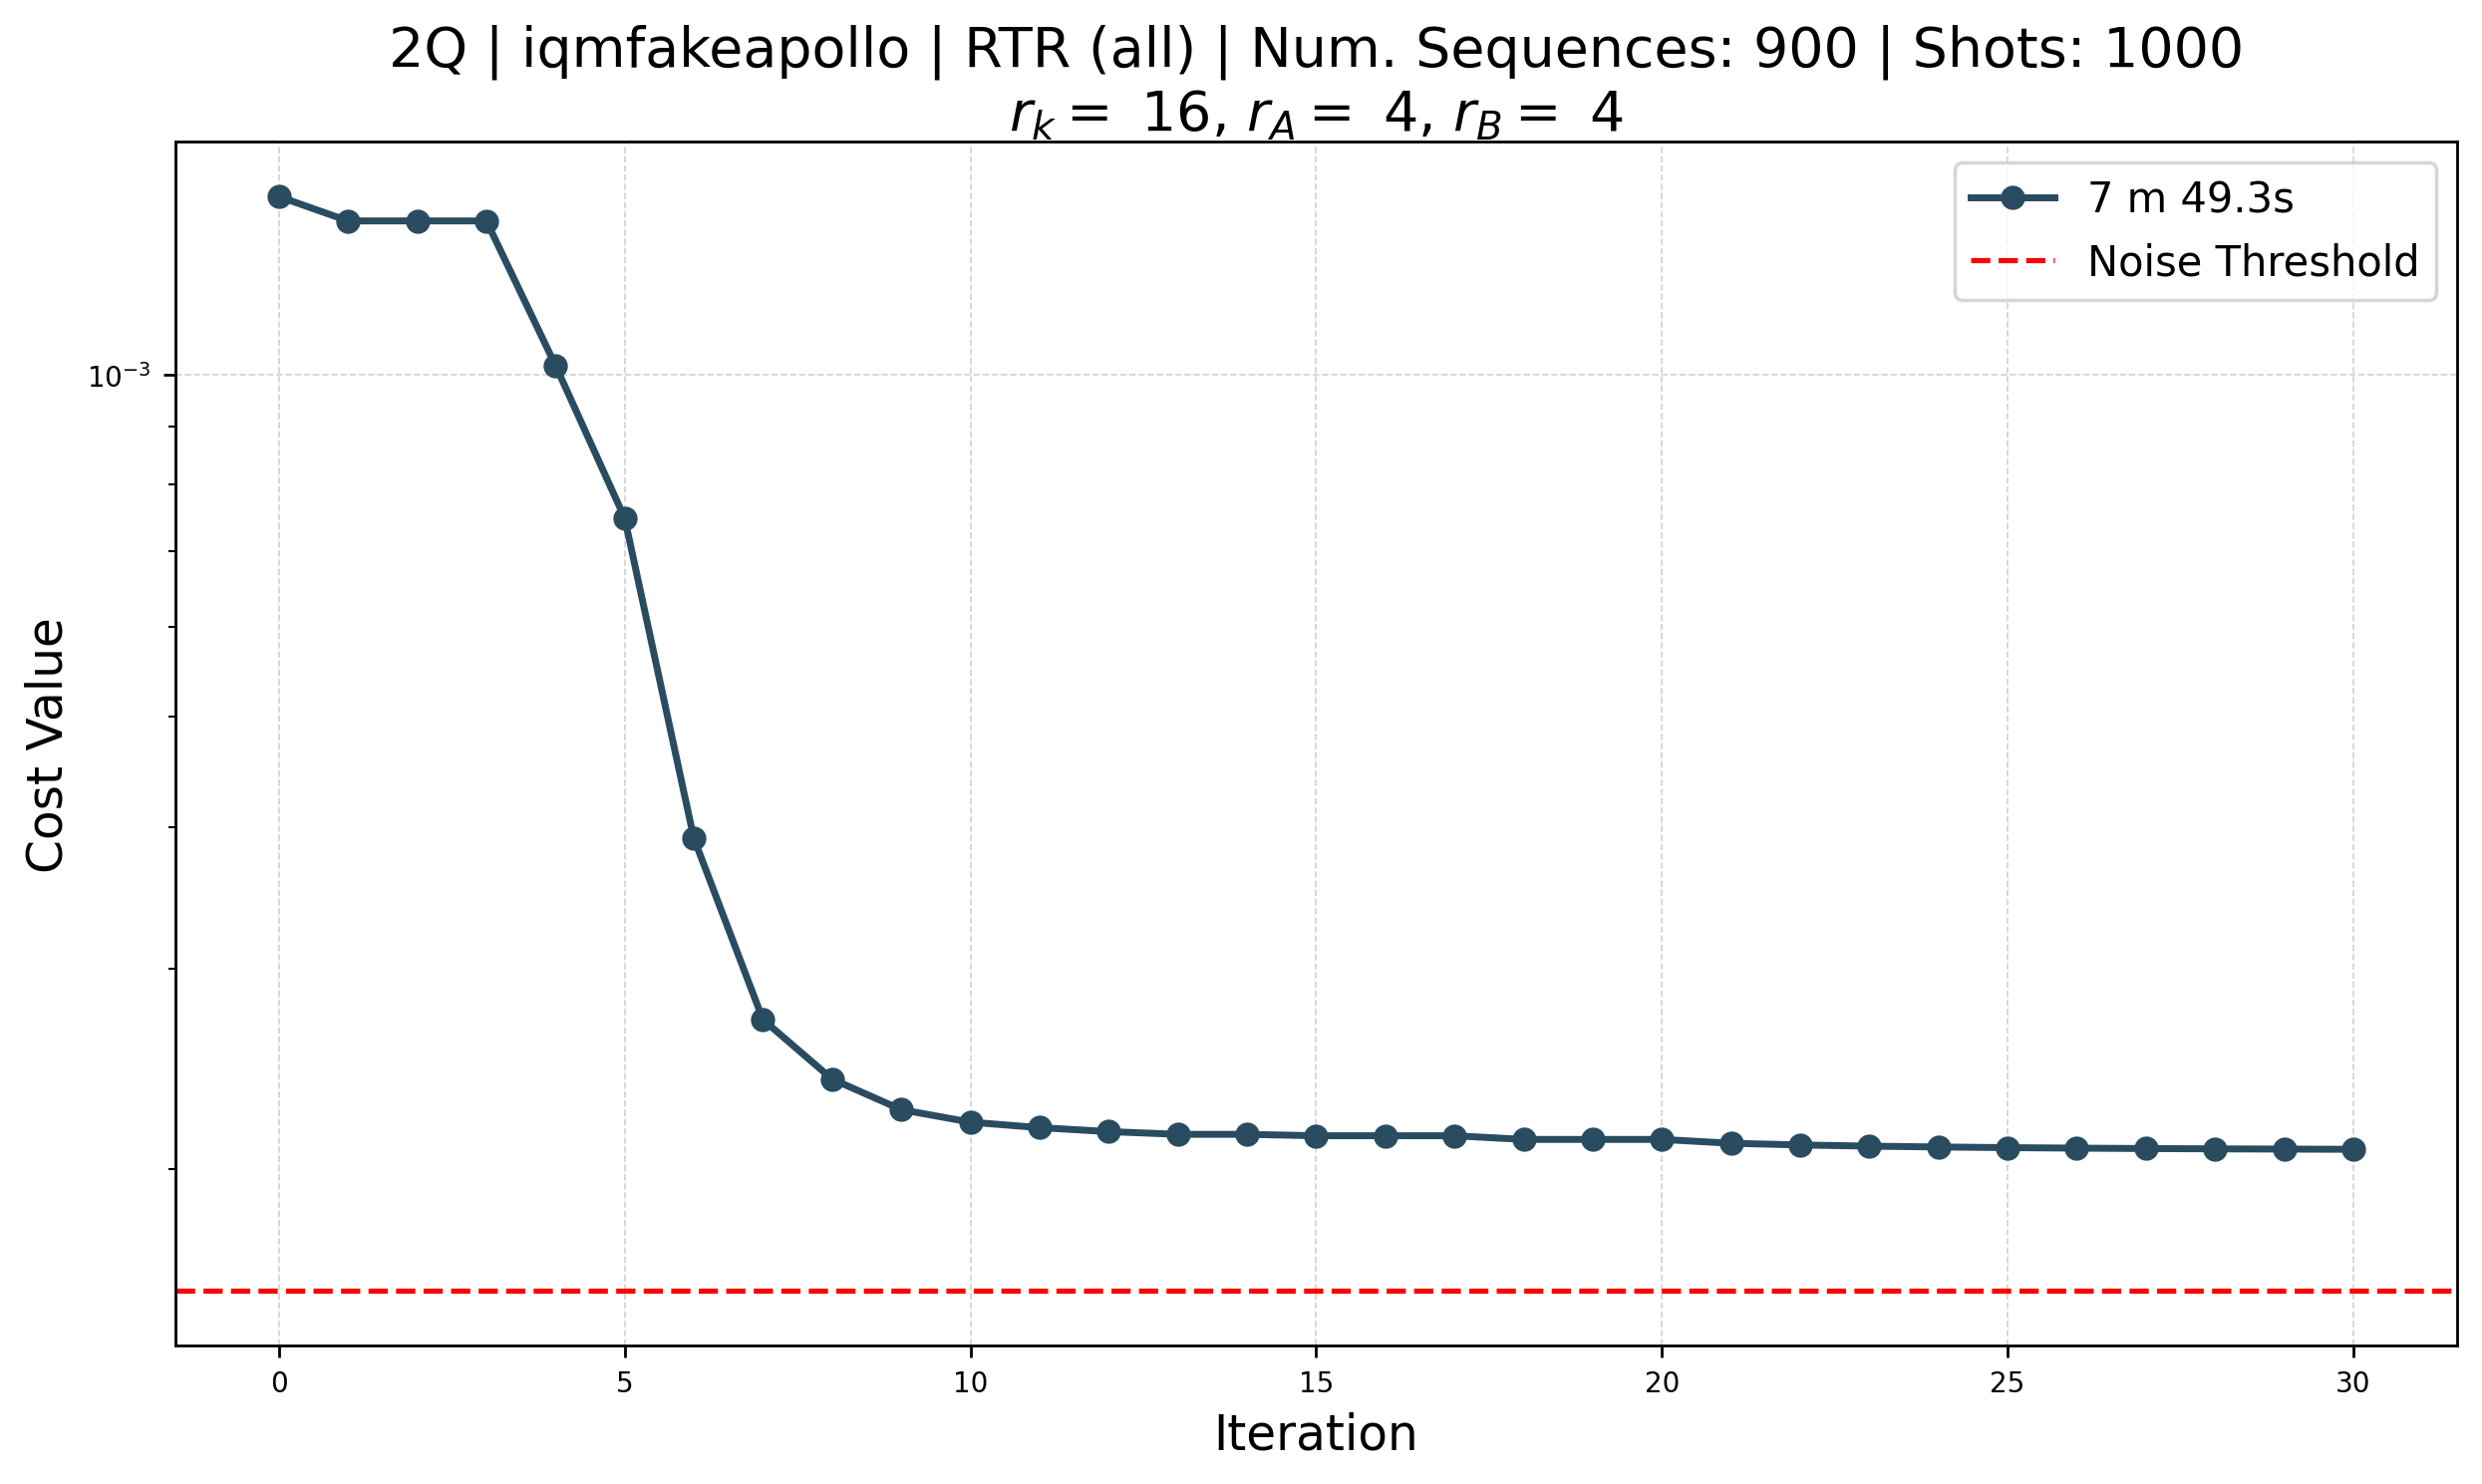

In [25]:
plot_cost_function(
    cost_array=[cost_fn_history],
    labels=[r"7 m 49.3s"],
    comparison_yline=noise_threshold,
    comparison_label="Noise Threshold",
    title=f"{num_qubits_2}Q | {backend} | RTR (all) | Num. Sequences: {num_seq_2q} | Shots: {num_shots}" + "\n" + rf"$r_k =$ {kraus_rank_16}, $r_A =$ {dim_2q}, $r_B =$ {dim_2q}"
)

# Vertical generators

# At initial point

## Setup

In [47]:
# single kraus tensor
x_init = init_operators_jax_2q_rank_16["kraus_tensor_init"]
print(x_init.shape)
x_init = x_init[0]

n, p = get_isometry_dimensions_from_tensor(x_init, operator_type="kraus")
x_isom_init = tensor_to_isometry(x_init, n, p)

(6, 16, 4, 4)


In [49]:
vert_velocity_rnd = random_vertical_velocity(x_isom_init, seed=42, dim_A=kraus_rank_16)
is_in_tangent_space(x=x_isom_init, z=vert_velocity_rnd)

Array(True, dtype=bool)

In [55]:
# check anti-hermitian basis
anti_hermitian_basis = generate_anti_hermitian_basis(dim=kraus_rank_16)
print(anti_hermitian_basis.shape)
all(is_anti_hermitian(A) for A in anti_hermitian_basis)

(256, 16, 16)


True

In [58]:
# construct the fundamental vertical vectors from this basis
vertical_fundamental_vectors = generate_vertical_fundamental_vectors(x=x_isom_init, dim_A=kraus_rank_16)
print(vertical_fundamental_vectors.shape)
all(is_in_tangent_space(x=x_isom_init, z=v) for v in vertical_fundamental_vectors)

(256, 64, 4)


True

In [61]:
# We now have to vectorize this basis
vect_vertical_fundamental_vectors = vertical_fundamental_vectors.reshape(vertical_fundamental_vectors.shape[0], -1)
print(vect_vertical_fundamental_vectors.shape)

(256, 256)


In [ ]:
# do we stack the real and imaginary part or do we use the wirtinger representation?
vect_vertical_fundamental_vectors_real = jnp.concatenate([vect_vertical_fundamental_vectors.real, vect_vertical_fundamental_vectors.imag], axis=1)
print(vect_vertical_fundamental_vectors_real.shape)

(256, 512)


(512, 256)

In [86]:
vect_vertical_fundamental_vectors_wirtinger = jnp.concatenate([vect_vertical_fundamental_vectors, jnp.conj(vect_vertical_fundamental_vectors)], axis=1)
print(vect_vertical_fundamental_vectors_wirtinger.shape)

(256, 512)


In [111]:
tol = 1e-6
rank_real, s_values_real = compute_manual_rank(vect_vertical_fundamental_vectors_real, tol=tol)
print("Vertical space dimension: ", rank_real)

Vertical space dimension:  256


In [112]:
rank_complex, s_values_complex = compute_manual_rank(vect_vertical_fundamental_vectors, tol=tol)
print("Vertical space dimension: ", rank_complex)

Vertical space dimension:  256


In [113]:
rank_wirtinger, s_values_wirtinger = compute_manual_rank(vect_vertical_fundamental_vectors_wirtinger, tol=tol)
print("Vertical space dimension: ", rank_wirtinger)

Vertical space dimension:  256


## Visualization

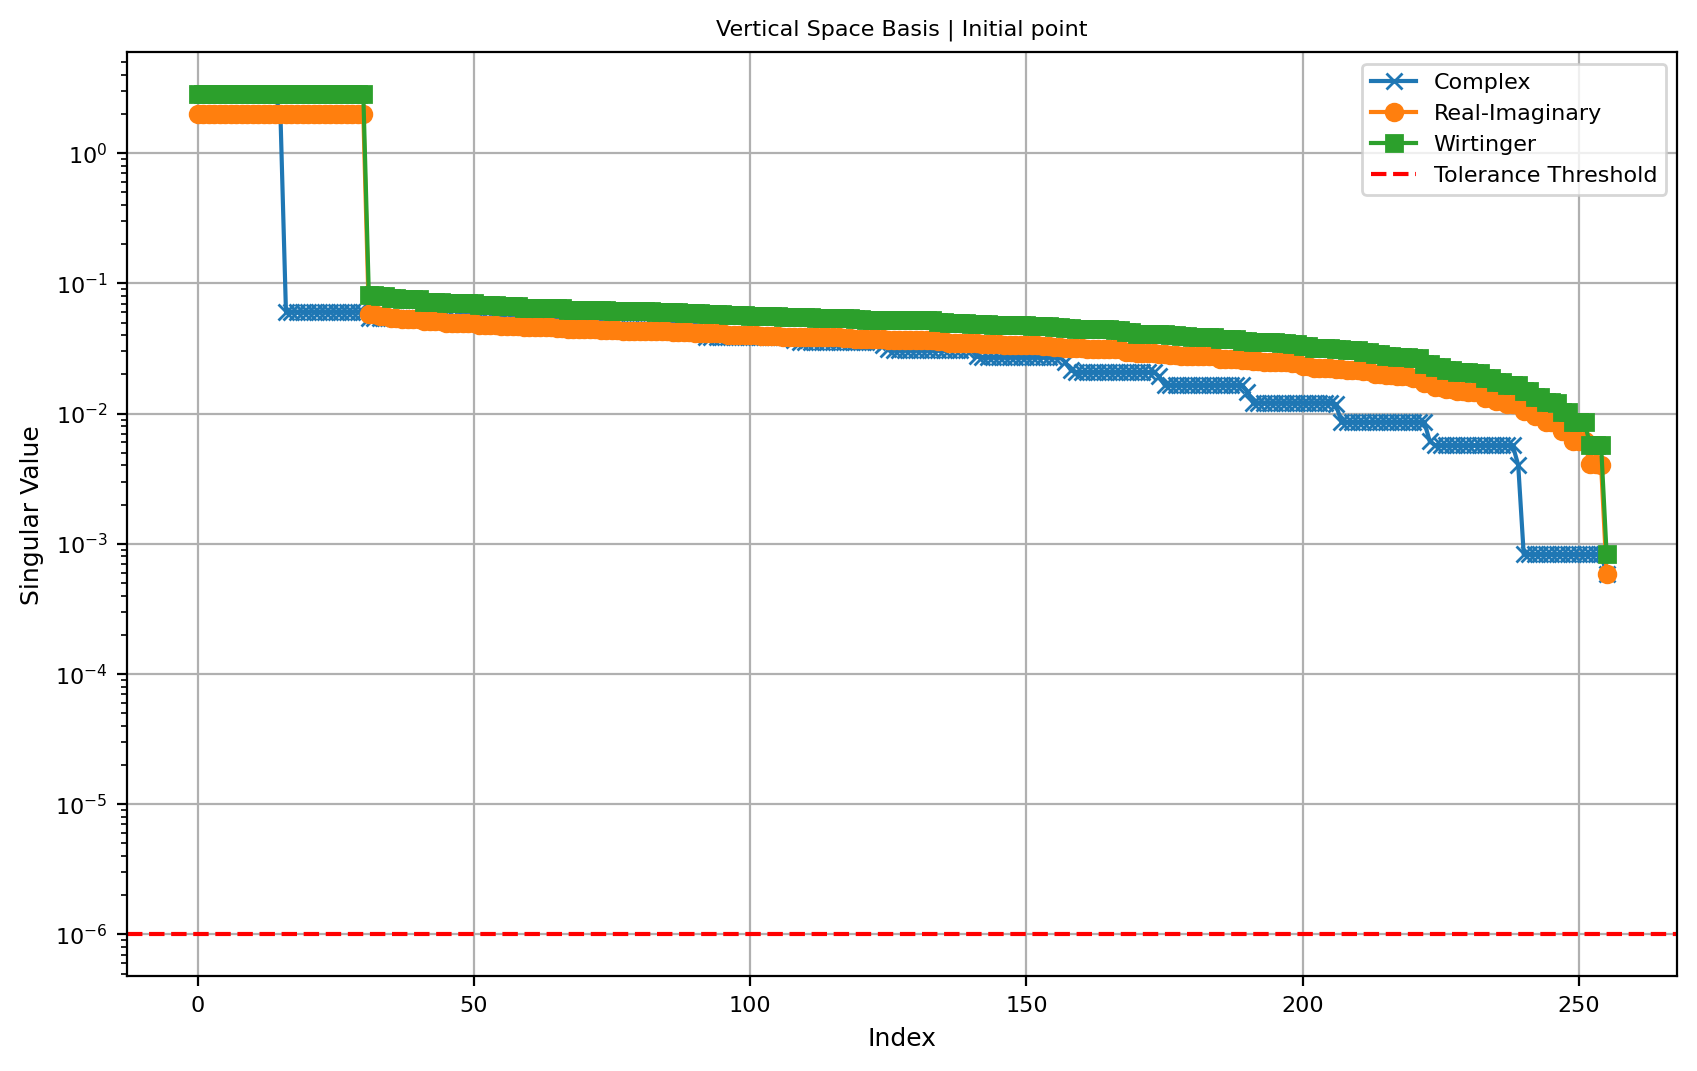

In [114]:
# plot the singular values:
plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_complex, marker='x', label="Complex")
plt.semilogy(s_values_real, marker='o', label="Real-Imaginary")
plt.semilogy(s_values_wirtinger, marker='s', label="Wirtinger")
plt.axhline(tol, color='red', linestyle='--', label='Tolerance Threshold')
plt.title('Vertical Space Basis | Initial point')
plt.xlabel('Index')
plt.ylabel('Singular Value')
plt.legend()
plt.grid(True)
plt.show()

# At final point

In [93]:
# single kraus tensor
x_opt = optimized_operators["kraus"][0]
print(x_opt.shape)
x_isom_opt = tensor_to_isometry(x_opt, n, p)
print(x_isom_opt.shape)

# construct the fundamental vertical vectors from this basis
vert_fund_vects_opt = generate_vertical_fundamental_vectors(x=x_isom_opt, dim_A=kraus_rank_16)
print(vert_fund_vects_opt.shape)
all(is_in_tangent_space(x=x_isom_opt, z=v) for v in vert_fund_vects_opt)

(16, 4, 4)
(64, 4)
(256, 64, 4)


True

In [99]:
vert_basis_opt_complex = vert_fund_vects_opt.reshape(vert_fund_vects_opt.shape[0], -1)
vert_basis_opt_real = jnp.concatenate([vert_basis_opt_complex.real, vert_basis_opt_complex.imag], axis=1)
vert_bassis_opt_wirtinger = jnp.concatenate([vert_basis_opt_complex, jnp.conj(vert_basis_opt_complex)], axis=1)

In [109]:
tol = 1e-6

rank_opt_real, s_values_opt_real = compute_manual_rank(vert_basis_opt_real, tol=tol)
print("Vertical space dimension: ", rank_opt_real)

rank_opt_complex, s_values_opt_complex = compute_manual_rank(vert_basis_opt_complex, tol=tol)
print("Vertical space dimension: ", rank_opt_complex)

rank_opt_wirtinger, s_values_opt_wirtinger = compute_manual_rank(vert_bassis_opt_wirtinger, tol=tol)
print("Vertical space dimension: ", rank_opt_wirtinger)

Vertical space dimension:  255
Vertical space dimension:  240
Vertical space dimension:  255


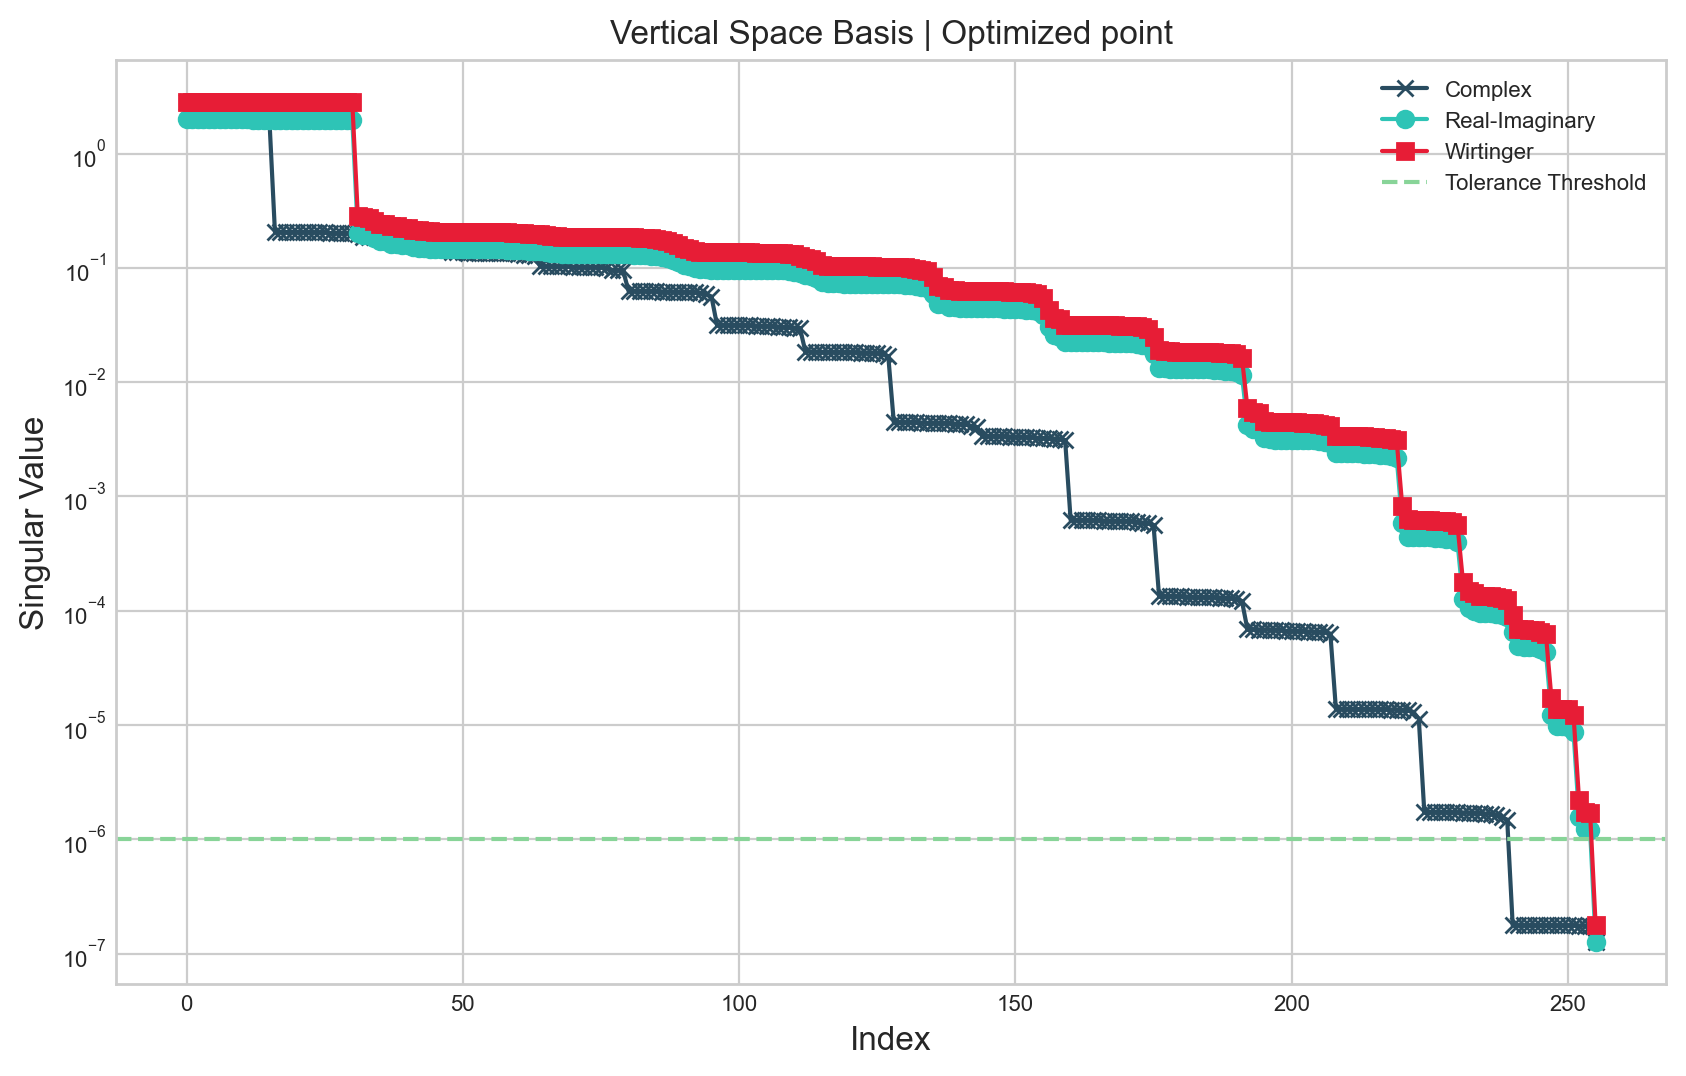

In [188]:
# plot the singular values:
plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_opt_complex, marker='x', label="Complex", color=COLOUR_PALETTE[0])
plt.semilogy(s_values_opt_real, marker='o', label="Real-Imaginary", color=COLOUR_PALETTE[1])
plt.semilogy(s_values_opt_wirtinger, marker='s', label="Wirtinger", color=COLOUR_PALETTE[2])
plt.axhline(tol, linestyle='--', label='Tolerance Threshold', color=COLOUR_PALETTE[3])
plt.title('Vertical Space Basis | Optimized point', fontsize=12)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Singular Value', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# At random point

In [164]:
step_size = 1e-6
random_kraus_tensor = randKrausSet(num_gate_sequences=5, dim=dim_2q, rank_kraus=kraus_rank_16, a=step_size, seed=42)
idx = 0
x_rnd = random_kraus_tensor[idx]
x_rnd_isom = tensor_to_isometry(x_rnd, n, p)
print(x_rnd.shape)

# construct the fundamental vertical vectors from this basis
vert_fund_vects_rnd = generate_vertical_fundamental_vectors(x=x_rnd_isom, dim_A=kraus_rank_16)
print(vert_fund_vects_rnd.shape)
all(is_in_tangent_space(x=x_rnd_isom, z=v) for v in vert_fund_vects_rnd)

(16, 4, 4)
(256, 64, 4)


True

In [165]:
x_test = x_rnd.reshape((kraus_rank_16*dim_2q, dim_2q))
x_test

array([[ 1.00000000e+00+5.24887132e-08j,  8.85234521e-08-1.77183834e-09j,
        -4.06937144e-08-6.74532402e-08j,  9.58299611e-08-9.84969186e-08j],
       [-8.85234509e-08-1.77184036e-09j,  1.00000000e+00+2.78232496e-08j,
        -3.61349227e-08+3.72407122e-08j, -2.17512821e-08+7.00366284e-08j],
       [ 4.06937095e-08-6.74532542e-08j,  3.61349251e-08+3.72406968e-08j,
         1.00000000e+00-2.90954645e-08j,  3.52243652e-08-5.31776528e-09j],
       [-9.58299995e-08-9.84969337e-08j,  2.17512986e-08+7.00366215e-08j,
        -3.52243606e-08-5.31775831e-09j,  1.00000000e+00+2.56067561e-08j],
       [ 1.31391429e-08+4.66591715e-08j,  1.02545697e-07+6.04400710e-08j,
         1.14995642e-08+1.49563964e-08j, -1.10818589e-08+3.79811608e-08j],
       [ 5.50448775e-08-1.59634058e-08j,  6.63833554e-08+6.51210740e-09j,
        -5.15309671e-08+3.73570661e-08j,  6.21001135e-08+2.40206406e-08j],
       [-5.68883827e-08+4.61736288e-08j,  2.38668798e-08+2.90267955e-08j,
        -3.39959995e-10+6.705263

In [166]:
vert_basis_rnd_complex = vert_fund_vects_rnd.reshape(vert_fund_vects_rnd.shape[0], -1)
vert_basis_rnd_real = jnp.concatenate([vert_basis_rnd_complex.real, vert_basis_rnd_complex.imag], axis=1)
vert_basis_rnd_wirtinger = jnp.concatenate([vert_basis_rnd_complex, jnp.conj(vert_basis_rnd_complex)], axis=1)

In [168]:
tol = 1e-6
rank_rnd_real, s_values_rnd_real = compute_manual_rank(vert_basis_rnd_real, tol=tol)
print("Vertical space dimension: ", rank_rnd_real)

rank_rnd_complex, s_values_rnd_complex = compute_manual_rank(vert_basis_rnd_complex, tol=tol)
print("Vertical space dimension: ", rank_rnd_complex)

rank_rnd_wirtinger, s_values_rnd_wirtinger = compute_manual_rank(vert_basis_rnd_wirtinger, tol=tol)
print("Vertical space dimension: ", rank_rnd_wirtinger)

Vertical space dimension:  31
Vertical space dimension:  16
Vertical space dimension:  31


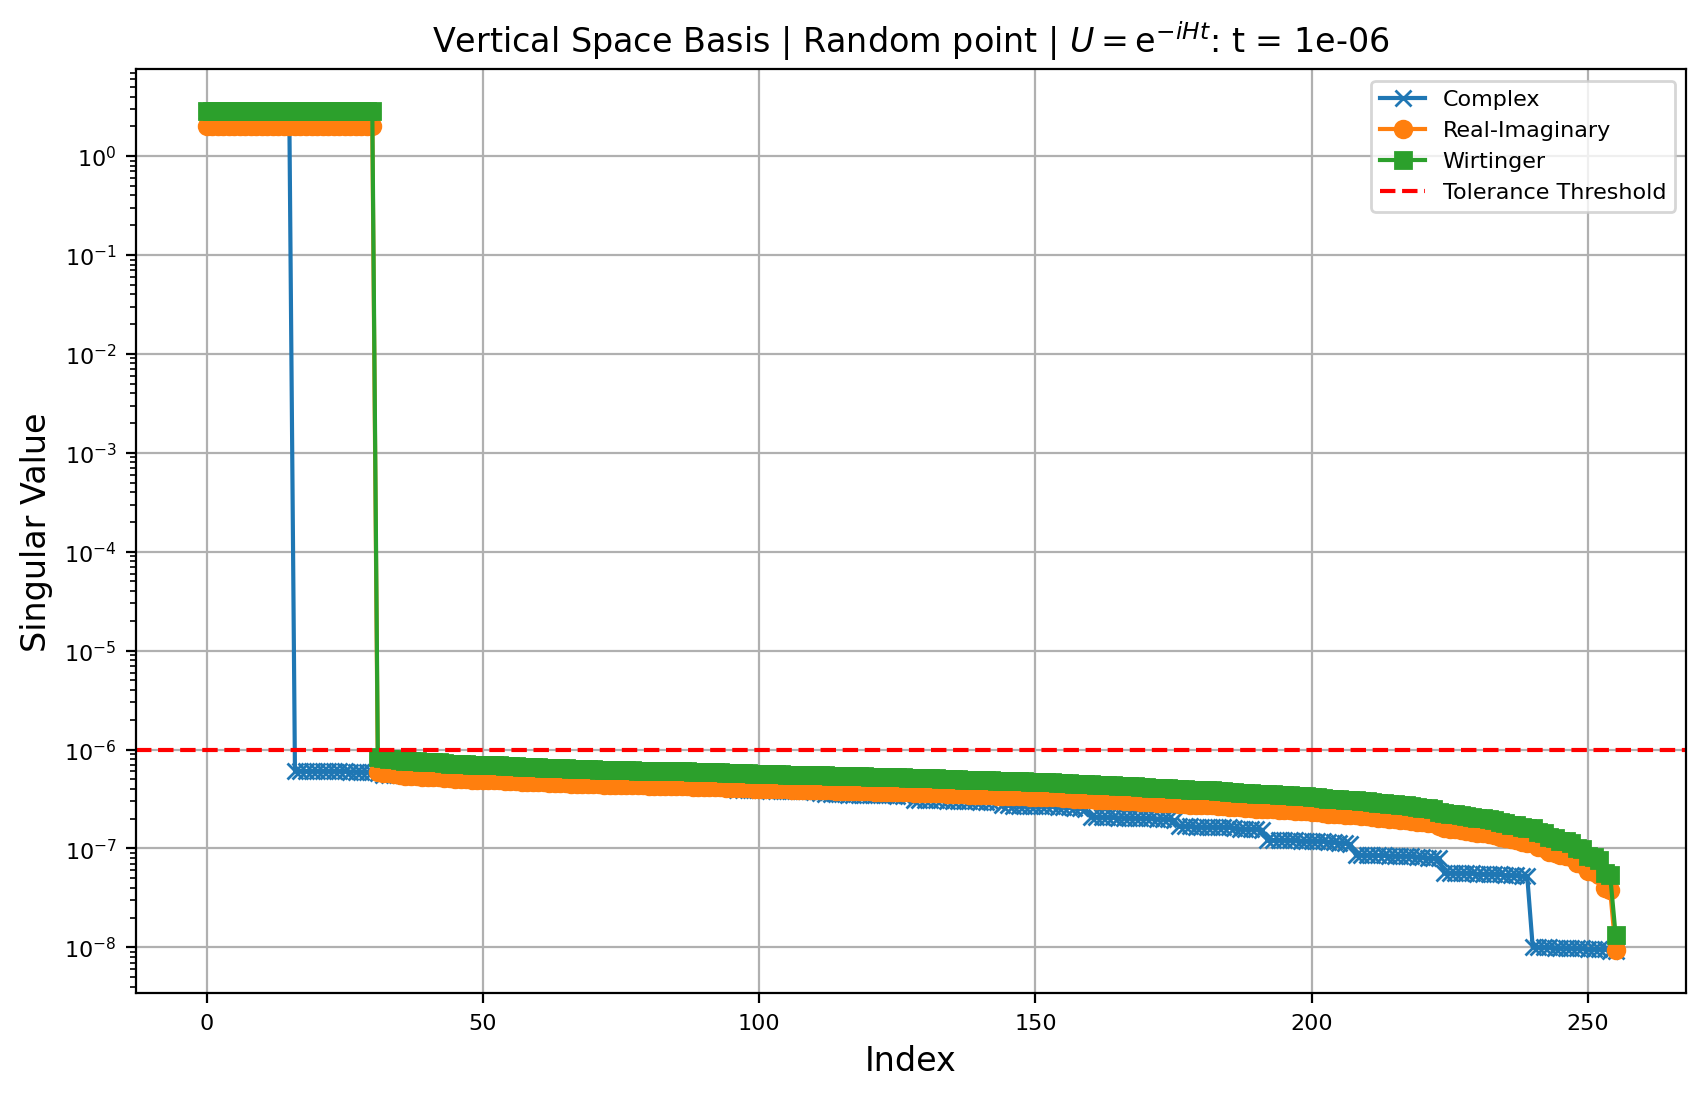

In [178]:
# plot the singular values:
plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_rnd_complex, marker='x', label="Complex")
plt.semilogy(s_values_rnd_real, marker='o', label="Real-Imaginary")
plt.semilogy(s_values_rnd_wirtinger, marker='s', label="Wirtinger")
plt.axhline(tol, color='red', linestyle='--', label='Tolerance Threshold')
plt.title(r'Vertical Space Basis | Random point | $U = \mathrm{e}^{-iHt}$' + f': t = {step_size}', fontsize=12)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Singular Value', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [208]:
kraus_rank_16

16

# All together:

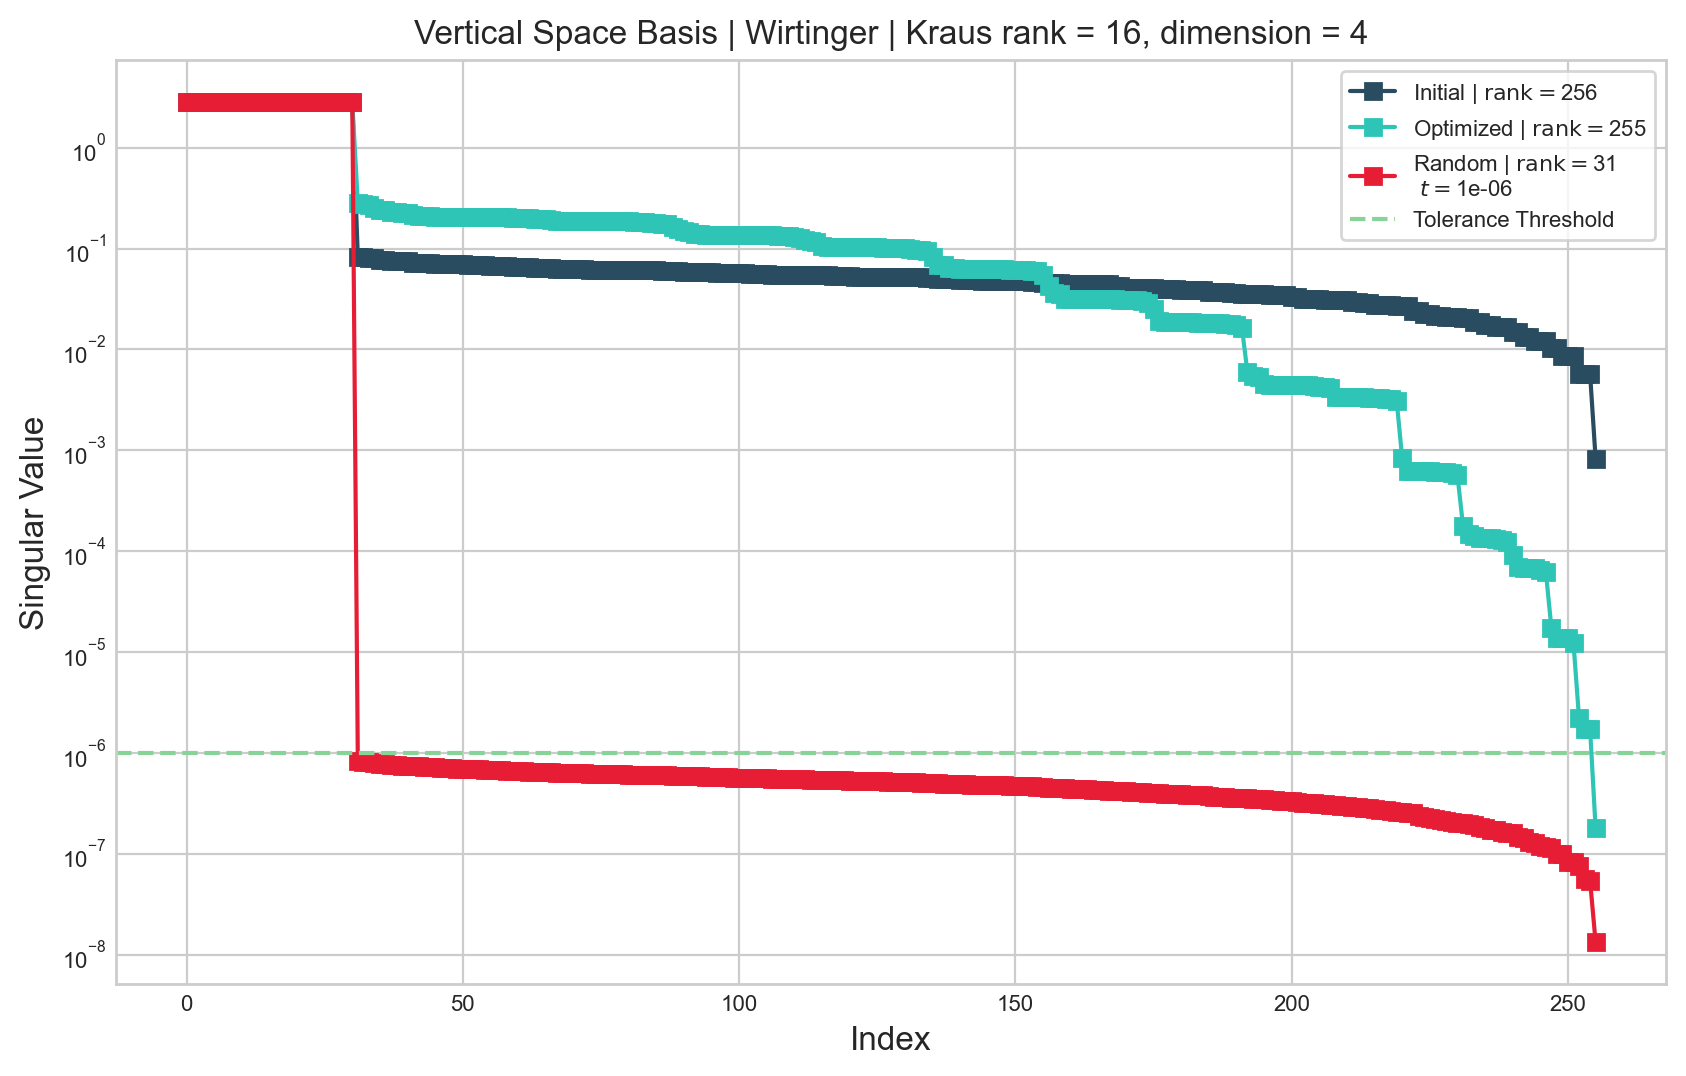

In [210]:
# plot the singular values:
plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_wirtinger, marker='s', label=r"Initial | $\mathrm{rank} = $" + f"{rank_wirtinger}", color=COLOUR_PALETTE[0])
plt.semilogy(s_values_opt_wirtinger, marker='s', label=r"Optimized | $\mathrm{rank} = $" + f"{rank_opt_wirtinger}", color=COLOUR_PALETTE[1])
plt.semilogy(s_values_rnd_wirtinger, marker='s', label=r"Random | $\mathrm{rank} = $" + f"{rank_rnd_wirtinger} \n" + r" $t=$" + f"{step_size}", color=COLOUR_PALETTE[2])
plt.axhline(tol, color=COLOUR_PALETTE[3], linestyle='--', label='Tolerance Threshold')
plt.title(f'Vertical Space Basis | Wirtinger | Kraus rank = {kraus_rank_16}, dimension = {dim_2q}', fontsize=12)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Singular Value', fontsize=12)
plt.legend(frameon=True)
plt.grid(True)
plt.show()

In [202]:
def plot_singular_value_distributions(
    singular_value_dict,
    tol=None,
    bins=28,
    title="Distribution of Singular Values",
    palette=COLOUR_PALETTE,
):
    """
    Plot overlapping histogram distributions of singular values on log10 scale.

    Parameters
    ----------
    singular_value_dict : dict[str, array-like]
        Mapping from label to singular values.
    tol : float | None
        Optional tolerance threshold to display as a vertical line.
    bins : int
        Number of histogram bins.
    title : str
        Plot title.
    palette : list[str] | None
        List of colors to use. If fewer colors than datasets are provided,
        colors are repeated cyclically.
    """
    plt.style.use("seaborn-v0_8-whitegrid")

    eps = 1e-16
    labels = list(singular_value_dict.keys())
    values = [jnp.asarray(v) for v in singular_value_dict.values()]
    log_values = [jnp.log10(jnp.clip(v, eps, None)) for v in values]

    all_logs = jnp.concatenate(log_values)
    bin_edges = jnp.linspace(all_logs.min(), all_logs.max(), bins + 1)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

    for i, (label, log_vals) in enumerate(zip(labels, log_values)):
        color = palette[i % len(palette)]

        ax.hist(
            log_vals,
            bins=bin_edges,
            density=True,
            alpha=0.28,
            color=color,
            edgecolor=color,
            linewidth=1.2,
            label=label,
        )

        ax.hist(
            log_vals,
            bins=bin_edges,
            density=True,
            histtype="step",
            color=color,
            linewidth=2.0,
        )

        ax.axvline(
            log_vals.mean(),
            color=color,
            linestyle="--",
            linewidth=1.8,
            alpha=0.9,
        )

    if tol is not None and tol > 0:
        ax.axvline(
            jnp.log10(tol),
            color="black",
            linestyle=":",
            linewidth=2,
            alpha=0.85,
            label=rf"$\log_{{10}}(\mathrm{{tol}})$ = {jnp.log10(tol):.2f}",
        )

    ax.set_title(title, fontsize=15, pad=14, fontweight="semibold")
    ax.set_xlabel(r"$\log_{10}(\sigma)$", fontsize=13)
    ax.set_ylabel("Density", fontsize=13)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.22, linewidth=0.8)
    ax.legend(frameon=False, fontsize=11)

    plt.tight_layout()
    plt.show()

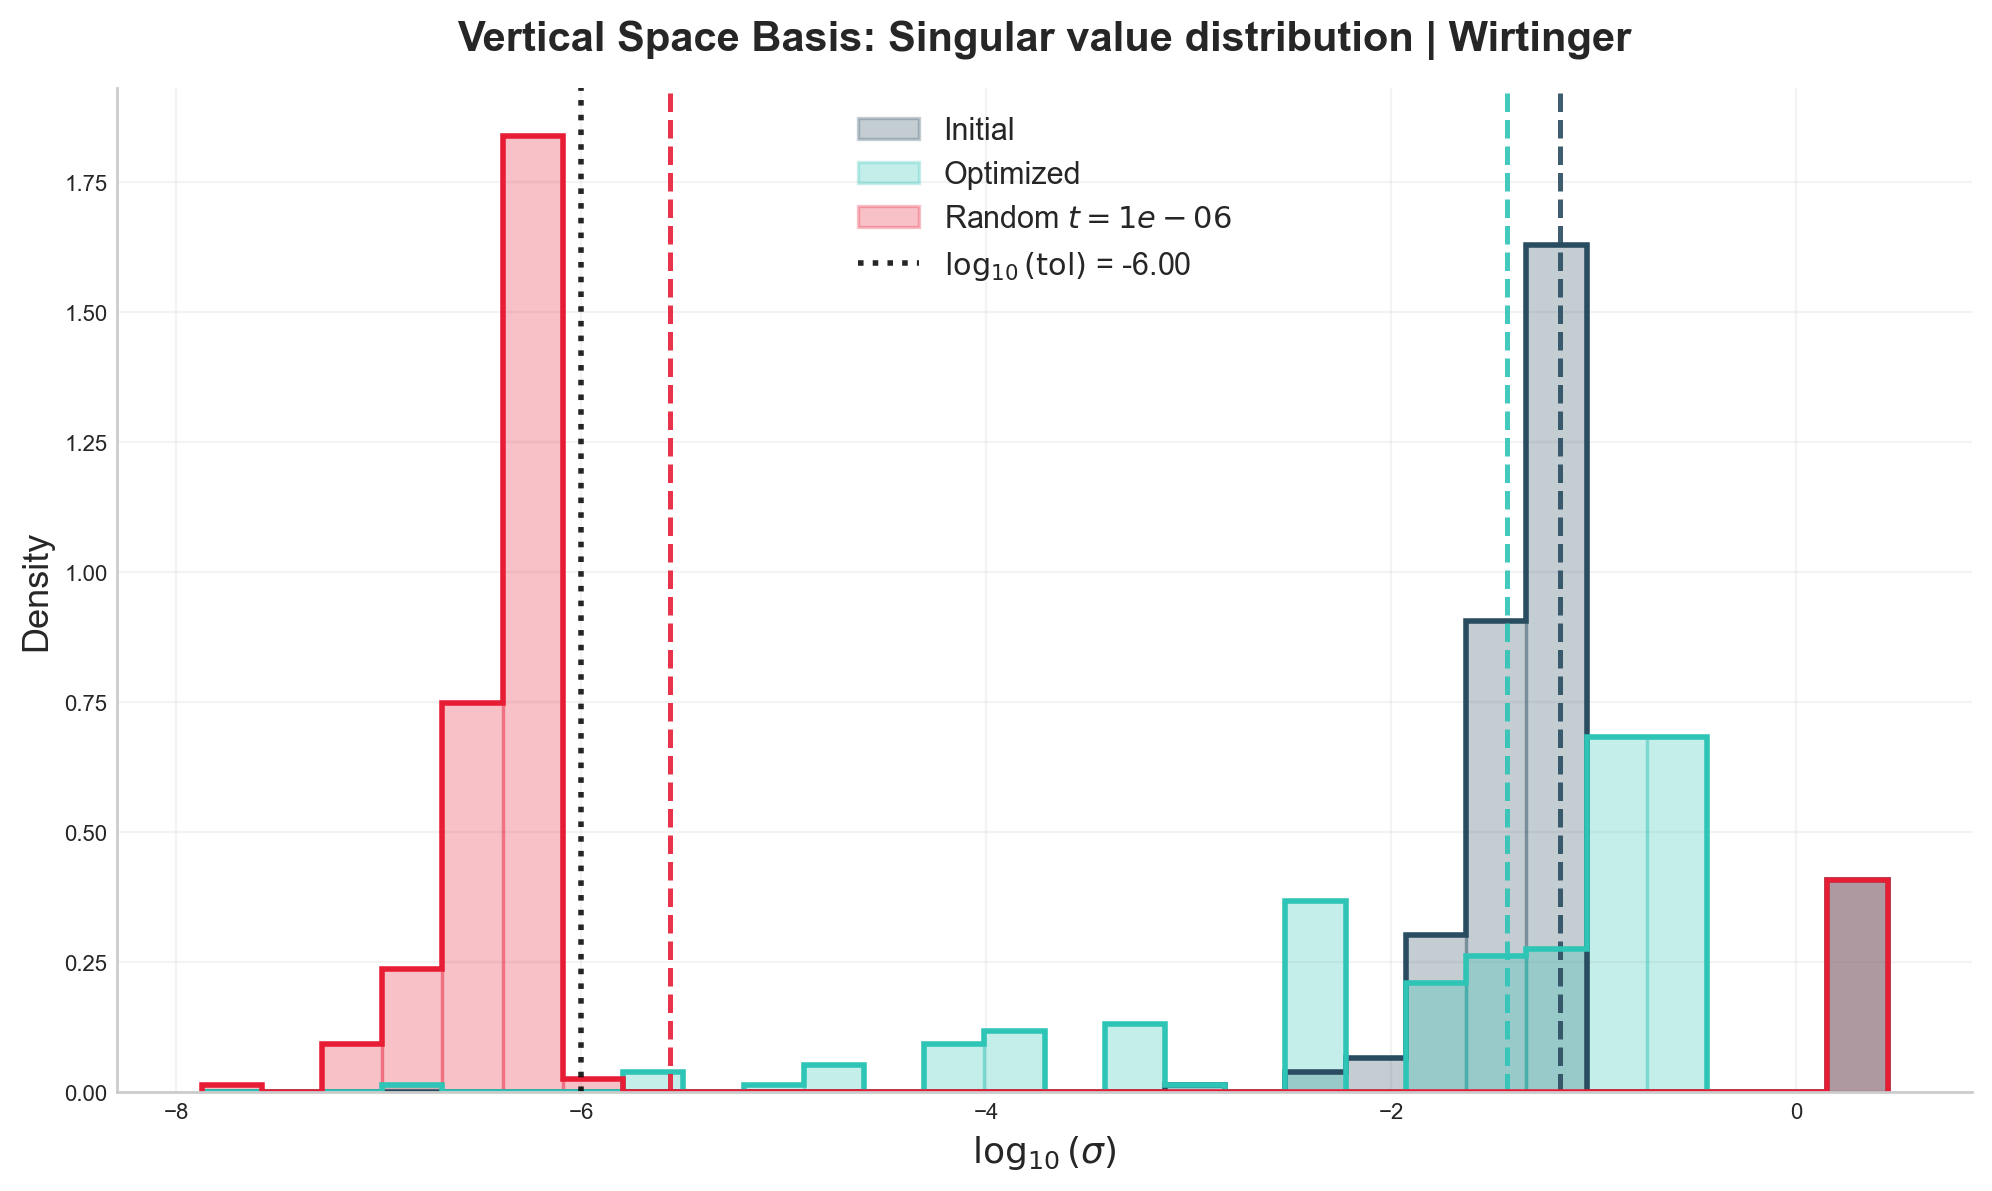

In [203]:
singular_values_dict = {
    "Initial": s_values_wirtinger,
    "Optimized": s_values_opt_wirtinger,
    rf"Random $t={step_size}$": s_values_rnd_wirtinger,
}

plot_singular_value_distributions(
    singular_values_dict,
    tol=tol,
    title="Vertical Space Basis: Singular value distribution | Wirtinger"
)

# Ideas:

1. Test if the behaviour is consistent among different gates at the same point from the kraus tensor. So, looking at other indices besides 0, will we also see consistently full rank for initial point and consistently lower rank for optimized point? If so, there is something there! If not, then what makes it have less rank?

2. Plot all 3 points in a single plot. Just to have an easier comparison.

3. Play around with the random kraus tensor, specifically witht the parameter a. The closest to identity the less rank? Makes sense! (or does it)?

    * Currently looking at a = 0, which means that the Kraus operator is just an incomplete identity. What can I say from this?